# 01. 시공간 데이터 EDA & 공간 인덱싱 (Module 2)

**목적**: 시뮬레이션 호출 로그를 Module 3(수요 예측) 입력으로 만들기 전에 데이터 특성을 확인하고, 전처리 설계(격자 크기·시간 단위·피처)의 근거를 남긴다.

| 섹션 | 답하는 질문 | 명세/평가 항목 |
|---|---|---|
| 1 개요 | 데이터가 얼마나·어느 기간·어떤 결측 | R6 |
| 2 시간 패턴 | 언제 수요가 몰리나 | R7 히트맵 |
| 3 공간 패턴 | 어느 셀이 핫스팟인가, H3 res 근거 | R1, Q1 |
| 4 POI zone 검증 | 시뮬이 쓰는 구역이 지도와 맞나 | M1 연계 |
| 5 정상성 | 시계열이 정상(stationary)인가 → 차분 필요? | 인터뷰 Q5 |
| 6 자기상관 | lag 몇 개까지 정보가 있나 → `max_lag` 근거 | R3 |
| 7 피처 유효성 | 어떤 피처 그룹이 예측에 기여하나 | Q2 |
| 8 외부 변수 | 날씨·요일이 수요와 상관 있나 | R4 |

> 데이터가 **1일 × 2시간**인 동안 나온 결론은 모두 *예비*다. 다일 데이터(T7)로 재실행하면 이 노트북을 그대로 다시 돌리면 된다.

In [1]:
import os, sys, glob, warnings
ROOT = os.path.abspath("..")
sys.path.insert(0, ROOT); os.chdir(ROOT)
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from config_loader import CFG
from module2_preprocessing.pipeline import load_logs, build_feature_table
from module2_preprocessing.spatial_indexing import SpatialIndexer
from module2_preprocessing.time_series_prep import TimeSeriesPreprocessor
from eda import eda_utils as E

LOGS = sorted(glob.glob("data/sim_logs/demand_log_*.csv"))
print("로그 파일:", [os.path.basename(p) for p in LOGS])
print(f"설정: H3 res={CFG['h3_resolution']}, freq={CFG['freq']}, max_lag={CFG['max_lag']}, horizons={CFG.get('forecast_horizons', 6)}")

[안내] config.json에서 설정값을 불러왔습니다.
[캐시 사용] '강남역' → 강남역, 강남대로, 역삼1동, 강남구, 서울특별시, 06615, 대한민국
[안내] '강남역' 좌표를 실시간 API(Nominatim)로 조회했습니다.


로그 파일: ['demand_log_20260910_180831_patrol.csv']
설정: H3 res=9, freq=5min, max_lag=12, horizons=6


## 1. 데이터 개요

In [2]:
logs = load_logs(LOGS)
feat = build_feature_table(LOGS)                       # 전체 파이프라인 (누락칸 제거된 학습용 테이블)
feat_all = build_feature_table(LOGS, dropna=False, verbose=False)   # EDA용: 앞뒤 칸 제거 안 함
agg = feat_all[["time_bucket", "h3_index", "demand"]].copy()
display(E.overview(feat, logs))

[로그] 1개 파일, 2,870건, 2026-09-07 09:00:11 ~ 2026-09-07 10:59:59
[로그] 1개 파일, 2,870건, 2026-09-07 09:00:11 ~ 2026-09-07 10:59:59
공간 인덱싱(H3 resolution=9 / Geohash 7자리) 변환 중... (2,870행)
변환 완료! 0.01초, H3 셀 22개
[외부 데이터] 날씨 파일 사용: weather_강남역_2026-08-31_2026-09-10.csv (264시간, 2026-08-31 00:00:00 ~ 2026-09-10 23:00:00)
[외부 데이터] 병합 완료: 결측 0.0% (tolerance 3h), 보간 0행
시계열 파생변수 생성: lag 12개, rolling 6/12/1h(12칸), 지난주 동일칸(2016칸 전), 시간 피처 15개, 타겟 t+1~t+6
  앞부분(lag/rolling 계산 불가) + 뒷부분(미래 타겟 없음) 396행 제거 → 132행
[피처 테이블] 132행 × 피처 40개, 셀 22개, 시간칸 6개 (5min), 타겟 ['y_h1', 'y_h2', 'y_h3', 'y_h4', 'y_h5', 'y_h6']
[로그] 1개 파일, 2,870건, 2026-09-07 09:00:11 ~ 2026-09-07 10:59:59


,값
항목,
호출 건수,"2,870"
기간,2026-09-07 09:00:11 ~ 2026-09-07 10:59:59 (0 d...
일수,1
H3 셀 수,22
시간칸 수(피처 테이블),6
피처 테이블 행,132
수요 0인 칸 비율,35.6%
셀당 평균 수요/칸,1.86
날씨 결측 비율,0.0%


## 2. 시간 패턴 — 언제 몰리나

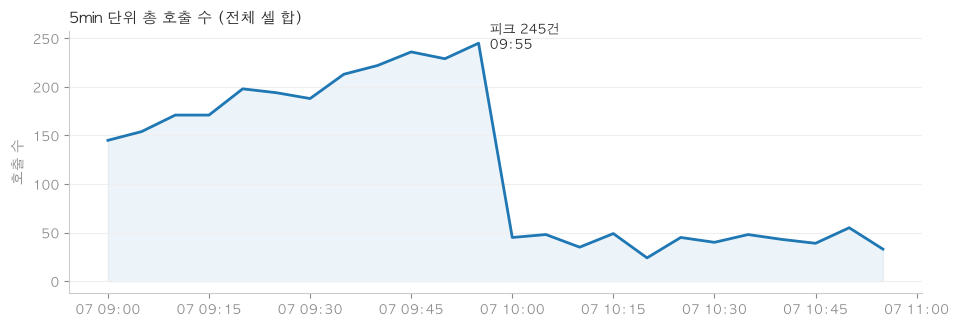

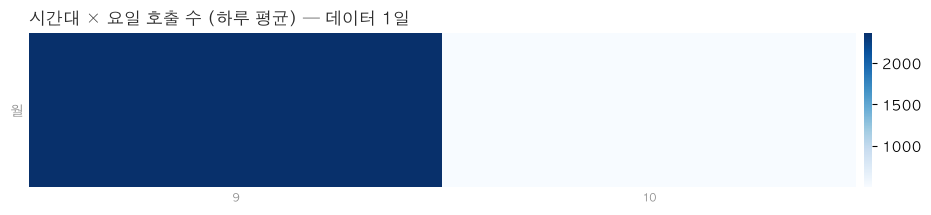

피크: 09/07 09:55 245건 / 최저: 10:20 24건 / 데이터 1일
※ 요일별 비교는 데이터가 7일 이상 있어야 의미가 있음 — 현재는 예비.


In [3]:
fig, s = E.plot_time_curve(agg, CFG["freq"]); plt.show()
fig, tab = E.hour_dow_heatmap(agg); plt.show()
n_days = agg["time_bucket"].dt.date.nunique()
print(f"피크: {s.idxmax():%m/%d %H:%M} {s.max()}건 / 최저: {s.idxmin():%H:%M} {s.min()}건 / 데이터 {n_days}일")
if n_days < 7:
    print("※ 요일별 비교는 데이터가 7일 이상 있어야 의미가 있음 — 현재는 예비.")

**결론(예비)**: 시뮬레이션 규칙(`company_start/end_hour`)대로 출근 시간대에 수요가 급증하고 창이 닫히면 급락한다. 이 '규칙 → 데이터' 대응이 보이는 것 자체가 Module 1 로그가 Module 2 입력으로 쓸 수 있다는 검증이다.

## 3. 공간 패턴 — 어느 셀이 핫스팟인가, 왜 res 9인가

,총수요,평균,최대,비율
h3_index,,,,
8930e1ca2bbffff,479,19.96,51,16.7%
8930e1ca217ffff,463,19.29,51,16.1%
8930e1ca04bffff,403,16.79,38,14.0%
8930e1ca287ffff,357,14.88,39,12.4%
8930e1ca28fffff,245,10.21,23,8.5%
8930e1ca05bffff,230,9.58,22,8.0%
8930e1ca28bffff,168,7.00,17,5.9%
8930e1ca283ffff,124,5.17,17,4.3%
8930e1ca2a3ffff,76,3.17,8,2.6%


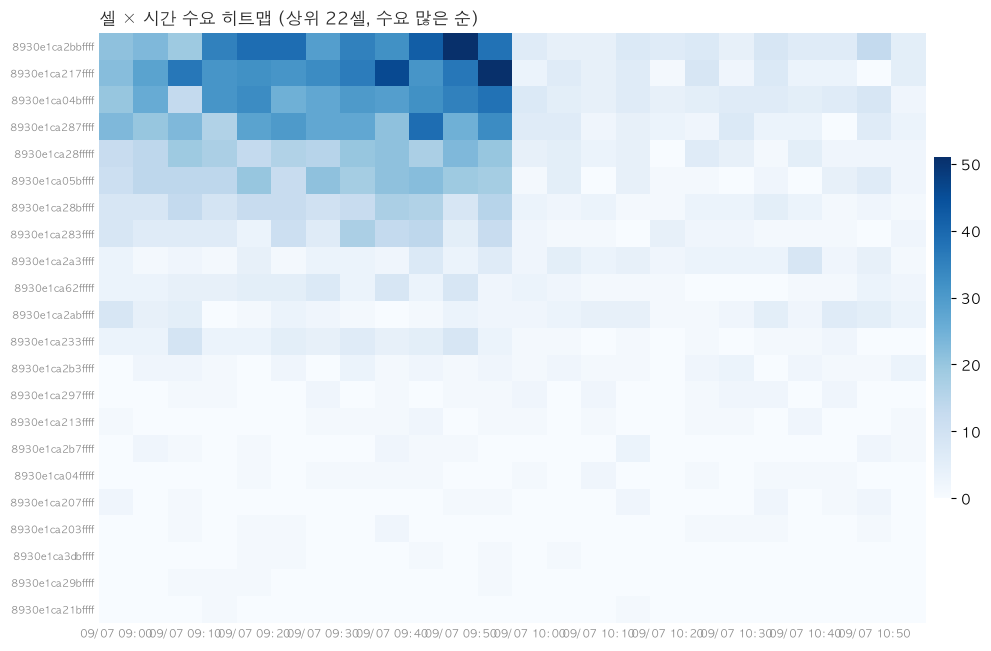

,resolution,셀 변 길이(m),셀 수,셀당 평균 수요/10분,셀당 중앙값 수요/10분,수요 0인 칸 비율(%),최다 셀 점유율(%),lag-1 자기상관(셀 평균),학습 행 수(lag6 제거 후)
0,7,1406,3,79.72,25.5,2.8,86.0,0.792,18
1,8,531,7,34.17,13.0,11.9,35.1,0.603,42
2,9,201,22,10.87,3.0,20.5,16.7,0.296,132
3,10,76,70,3.42,1.0,37.0,8.0,0.165,420


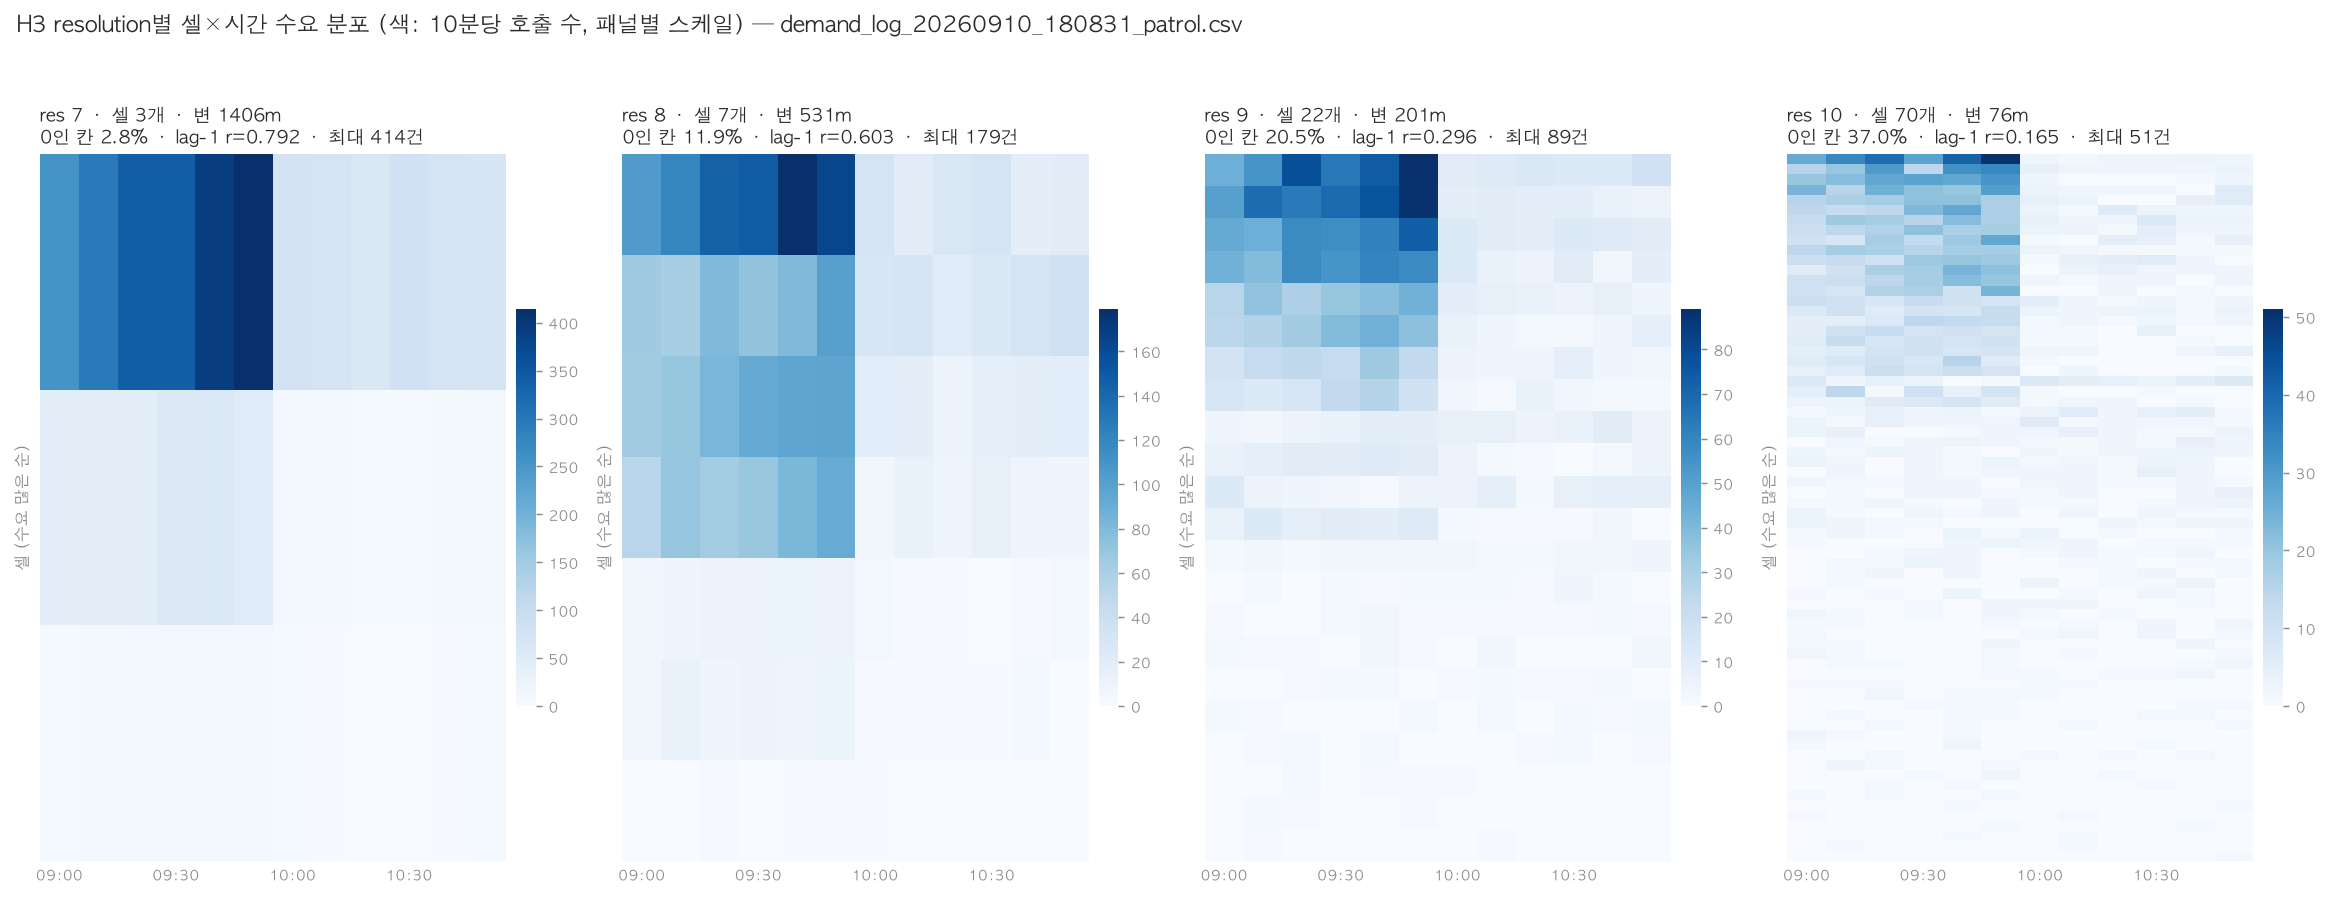

In [4]:
display(E.top_cells(agg, 10))
fig, mat = E.cell_time_heatmap(agg); plt.show()
res_tab = pd.read_csv("data/eda/h3_resolution_summary.csv")
display(res_tab)
from IPython.display import Image
display(Image("data/eda/h3_resolution_compare.png", width=1000))

**결론**: res 8은 셀 7개에 최다 셀이 35%를 차지해 공간 정보가 거의 없고, res 10은 칸의 37%가 0이고 lag-1 자기상관이 0.17로 노이즈다. res 9(변 201m, 셀 22개)는 출근 핫스팟 5~6셀이 식별되면서 0인 칸이 20%로 감당 가능해 **res 9를 채택**했다. (`eda/h3_resolution_compare.py`)

## 4. POI zone 검증 — 시뮬이 쓰는 구역이 지도와 맞나

,카테고리,OSM POI 수,현재 zone edge 수(80m),edge 수 @40m,edge 수 @80m,edge 수 @120m,edge 수 @200m,80m 밖 POI(누락) 수,POI→edge 거리 중앙값(m)
0,학교,5,4,3,4,4,4,0,37.0
1,주택,70,28,25,28,28,28,5,28.5
2,회사,123,47,47,51,51,51,0,31.2
3,음식점,525,150,154,157,157,157,1,13.5
4,지하철입구,17,14,16,16,16,16,0,11.2
5,버스정류장,46,26,28,28,28,28,0,10.2


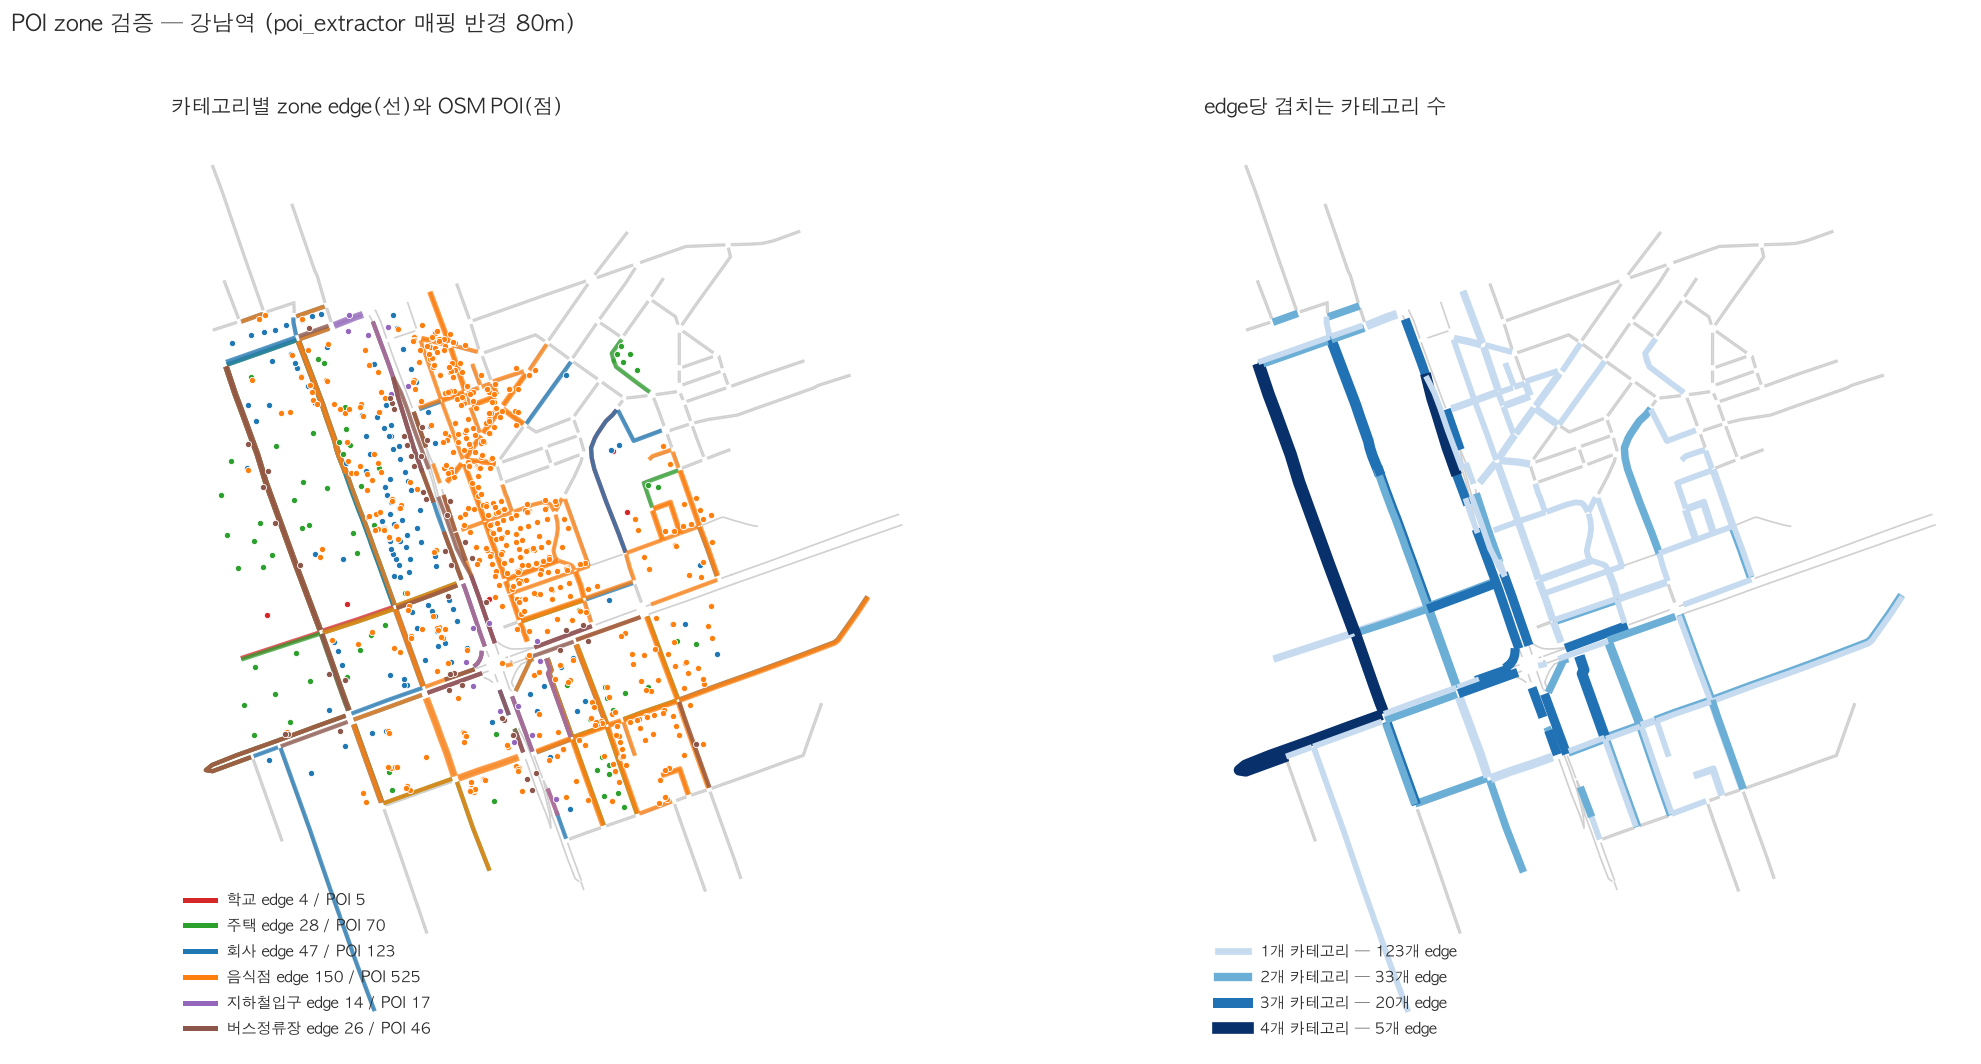

In [5]:
display(pd.read_csv("data/eda/poi_zone_summary.csv"))
display(Image("data/eda/poi_zone_map.png", width=1000))

**결론**: 매핑 반경(40~200m)은 결과에 영향이 없고, 겹침은 큰길(강남대로)에 여러 카테고리 POI가 몰려서 생긴다. 주택 POI가 블록 안쪽 골목이 아닌 큰길로 매핑되는 문제(주택 전용 edge 4/28)는 Module 1 담당과 공유. 상세: `docs/MODULE2_MANUAL.md`, `CHANGES_전처리.md`.

## 5. 정상성(Stationarity) — 차분이 필요한가

In [6]:
adf = E.stationarity(agg); display(adf)

,ADF 통계량,p-value,결론
계열,,,
원계열,-1.073,0.7259,비정상(단위근 의심)
1차 차분,-5.116,0.0000,정상(p<0.05)


**해석**: 원계열이 비정상이면(p≥0.05) 추세·수준 변화가 있다는 뜻이고, 1차 차분 후 정상이 되면 모델에 `diff_1`(직전 칸 대비 증감)과 이동평균을 넣어 수준 변화를 흡수하도록 한 현재 피처 설계가 타당하다. 트리 모델(XGBoost)은 정상성을 요구하지 않지만, ARIMA 등 통계 모델과 비교(인터뷰 질문)할 때 차분 차수의 근거가 된다.

## 6. 자기상관 — lag 몇 개까지 쓸 것인가

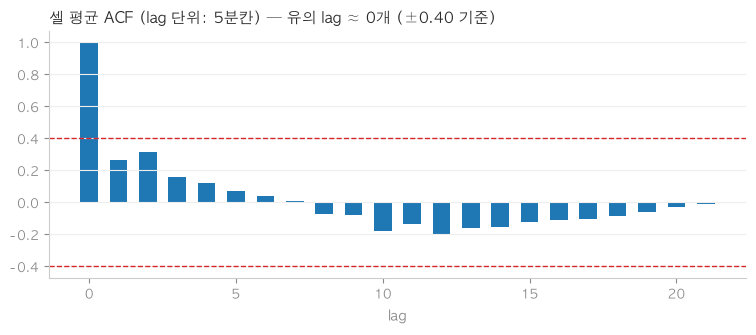

유의한 lag ≈ 0개 → config max_lag=12(=1시간)와 비교


In [7]:
fig, acf, sig = E.acf_by_cell(agg, max_lag=min(24, agg['time_bucket'].nunique() - 3))
if fig: plt.show(); print(f"유의한 lag ≈ {sig}개 → config max_lag={CFG['max_lag']}(=1시간)와 비교")
else: print("ACF 계산 불가 (칸 수 부족)")

## 7. 피처 유효성 검증 — 그룹별 기여 (ablation)

In [8]:
abl = E.feature_ablation(feat, target="y_h1")
display(abl)
print(f"모델: {abl.attrs['model']}, test 행 {abl.attrs['n_test']} — 나이브 대비 RMSE 감소가 곧 그 피처 그룹의 기여")

,피처 수,RMSE,MAE
피처 그룹,,,
나이브(=lag_1),1,1.758,1.273
lag만,12,1.966,1.459
+rolling/diff,19,1.826,1.275
+시간(calendar),29,1.759,1.241
+날씨(전체),40,1.759,1.241


모델: XGBoost, test 행 22 — 나이브 대비 RMSE 감소가 곧 그 피처 그룹의 기여


**해석**: '나이브(다음 칸=직전 칸)'보다 낮아야 피처가 의미가 있다. 그룹을 누적 추가했을 때 RMSE가 줄어드는 단계가 기여하는 그룹이고, 오히려 늘면 그 그룹은 현재 데이터에서 노이즈다(날씨가 상수면 늘 그렇다). test 행이 수십 개면 숫자 차이는 예비.

## 8. 외부 변수(날씨·요일·공휴일) 상관

In [9]:
display(E.external_correlation(feat_all))
src = feat_all["weather_source"].iloc[0] if "weather_source" in feat_all else "?"
print("날씨 출처:", src, "— fallback이면 scripts/fetch_weather_history.py 로 실데이터를 받은 뒤 재실행")

,고유값 수,상관(Pearson),판단
변수,,,
temperature,2,-0.959,강함
precipitation,1,NaN,변동 없음 → 현재 데이터로 판단 불가
is_holiday,1,NaN,변동 없음 → 현재 데이터로 판단 불가
dayofweek,1,NaN,변동 없음 → 현재 데이터로 판단 불가
hour,2,-0.959,강함


날씨 출처: observed — fallback이면 scripts/fetch_weather_history.py 로 실데이터를 받은 뒤 재실행


**결론(예비)**: 1일치 시뮬 로그에서는 요일·공휴일이 한 값이고, 시뮬 규칙에 날씨 입력이 없어 상관이 나올 수 없다. 이 섹션은 T7(다일 시뮬 또는 공개 데이터) 이후 의미가 생긴다. 병합 로직(1시간 관측 → 5분 칸, 과거 방향 asof, 결측 플래그)은 `tests/test_module2.py`로 검증돼 있다.

---
## 정리 — Module 2 설계 결정과 근거

| 결정 | 값 | 근거(섹션) |
|---|---|---|
| 공간 격자 | H3 res 9 (+Geohash 7) | §3 |
| 시간 단위 | 5분 | 명세 M3 (t+1~t+6, 5분) |
| lag 수 | 12 (1시간) | §6 ACF |
| 이동평균 | 30분 / 1시간 | §7 ablation |
| 타겟 | y_h1..y_h6 | 명세 M3 |
| 날씨 병합 | asof backward, tolerance 3h, 보간 ≤3h | T4 테스트 |
| 데이터 한계 | 1일 2시간 → 다일 필요 | §2, §8 |